# Robotic Arm Learning Rate Analysis

## Learning Rate Comparison Using Neural Networks

### Introduction

This project analyzes the effect of different learning rates on the training of a neural network for a two-joint robotic arm.

The model learns to predict the X and Y coordinates of the robotic-arm end effector from the two joint angles.

Three learning rates are compared using the Stochastic Gradient Descent (SGD) optimizer:

- **0.001** - Low learning rate
- **0.05** - Balanced learning rate
- **0.5** - High learning rate

The training and validation learning curves are analyzed to identify slow convergence, stable convergence, and fluctuating or unstable behavior.

The objective is to determine which learning rate provides the best balance between training progress and stability.

## Problem Statement

A robotic-arm model is trained with several learning rates and shows oscillation at one setting and slow progress at another.

The objective is to:

1. Analyze the observed learning curves.
2. Compare the convergence behavior of different learning rates.
3. Identify slow and unstable convergence.
4. Determine the learning rate that provides the best balance between stability and progress.

## Objectives

- Understand the effect of learning rate on neural-network training.
- Train a neural network to predict robotic-arm end-effector coordinates.
- Compare low, balanced, and high learning rates.
- Analyze training and validation loss curves.
- Compare final test performance.
- Select the most suitable learning rate based on convergence behavior and prediction performance.
  

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

All libraries imported successfully!
TensorFlow version: 2.21.0
NumPy version: 2.3.2
Pandas version: 2.3.2


In [6]:
# Set random seeds so that the experiment is reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("Random seeds set successfully!")

Random seeds set successfully!


In [7]:
# Path to the robotic-arm dataset
DATA_PATH = "../dataset/robotic_arm_data.csv"

# Load the dataset
data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (1000, 4)


,Joint_Angle_1,Joint_Angle_2,End_Effector_X,End_Effector_Y
0,67.417221,33.323927,0.226140,1.728019
1,171.128575,97.542171,-1.014864,-0.641671
2,131.758910,157.130250,-0.409272,-0.019646
3,107.758527,131.800480,-0.706653,0.267976
4,28.083355,145.181007,0.096921,0.538229


In [8]:
# Display basic information about the dataset

print("Dataset Information")
print("=" * 50)

print("\nNumber of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information

Number of rows: 1000
Number of columns: 4

Column Names:
['Joint_Angle_1', 'Joint_Angle_2', 'End_Effector_X', 'End_Effector_Y']

Data Types:
Joint_Angle_1     float64
Joint_Angle_2     float64
End_Effector_X    float64
End_Effector_Y    float64
dtype: object

Missing Values:
Joint_Angle_1     0
Joint_Angle_2     0
End_Effector_X    0
End_Effector_Y    0
dtype: int64


In [9]:
# Display statistical summary of the dataset

print("Statistical Summary")
print("=" * 50)

data.describe()

Statistical Summary


,Joint_Angle_1,Joint_Angle_2,End_Effector_X,End_Effector_Y
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,88.246180,91.263115,-0.282708,0.625967
std,52.584725,52.594181,0.851120,0.641857
min,0.833764,0.579287,-1.803455,-0.762946
25%,42.475188,43.393369,-0.891182,0.150715
50%,89.425328,93.372103,-0.340396,0.607791
75%,133.977526,136.883710,0.187618,1.149178
max,179.949181,179.894471,1.809649,1.805095


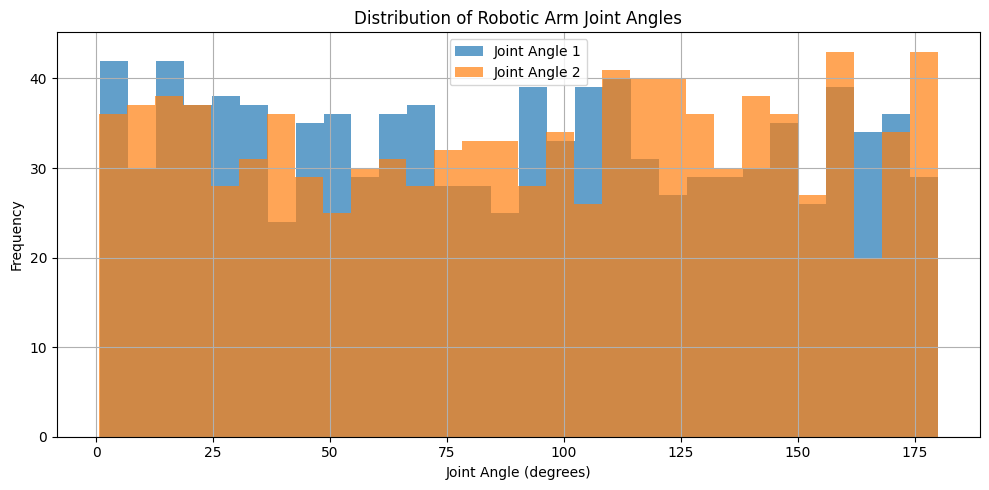

In [10]:
# Visualize the distribution of the two joint angles

plt.figure(figsize=(10, 5))

plt.hist(data["Joint_Angle_1"], bins=30, alpha=0.7, label="Joint Angle 1")
plt.hist(data["Joint_Angle_2"], bins=30, alpha=0.7, label="Joint Angle 2")

plt.title("Distribution of Robotic Arm Joint Angles")
plt.xlabel("Joint Angle (degrees)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Separate input features and target outputs

X = data[["Joint_Angle_1", "Joint_Angle_2"]].values

y = data[["End_Effector_X", "End_Effector_Y"]].values

print("Input features shape :", X.shape)
print("Target outputs shape :", y.shape)

Input features shape : (1000, 2)
Target outputs shape : (1000, 2)


In [12]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training input shape :", X_train.shape)
print("Testing input shape  :", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)

Training input shape : (800, 2)
Testing input shape  : (200, 2)
Training target shape: (800, 2)
Testing target shape : (200, 2)


In [13]:
# Normalize input and output data

input_scaler = StandardScaler()
output_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(X_train)
X_test_scaled = input_scaler.transform(X_test)

y_train_scaled = output_scaler.fit_transform(y_train)
y_test_scaled = output_scaler.transform(y_test)

print("Data normalization completed successfully!")

Data normalization completed successfully!


In [14]:
# Function to create the robotic-arm neural network

def create_model(learning_rate):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            2
        )
    ])

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model


print("Neural network function created successfully!")

Neural network function created successfully!


In [15]:
# Create a sample model to display its architecture

sample_model = create_model(0.05)

sample_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,218 (4.76 KB)

 Trainable params: 1,218 (4.76 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Learning rates used in the experiment

learning_rates = {
    "Low (0.001)": 0.001,
    "Balanced (0.05)": 0.05,
    "High (0.5)": 0.5
}

print("Learning rates selected for comparison:")
for name, rate in learning_rates.items():
    print(f"{name}: {rate}")

Learning rates selected for comparison:
Low (0.001): 0.001
Balanced (0.05): 0.05
High (0.5): 0.5


In [22]:
# Train the neural network using each learning rate

histories = {}
results = []

for name, learning_rate in learning_rates.items():

    print("\n" + "-" * 60)
    print(f"Training with learning rate: {learning_rate}")
    print("-" * 60)

    # Create a fresh model for each learning rate
    tf.random.set_seed(42)

    model = create_model(learning_rate)

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_split=0.20,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Store the training history
    histories[name] = history.history

    # Evaluate the model on the test data
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test_scaled,
        verbose=0
    )

    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    results.append({
        "Learning Rate": learning_rate,
        "Final Training Loss": final_train_loss,
        "Final Validation Loss": final_val_loss,
        "Test Loss": test_loss,
        "Test MAE": test_mae
    })

    print(f"Final Training Loss  : {final_train_loss:.6f}")
    print(f"Final Validation Loss: {final_val_loss:.6f}")
    print(f"Test Loss             : {test_loss:.6f}")
    print(f"Test MAE              : {test_mae:.6f}")

print("\nAll learning-rate experiments completed!")


------------------------------------------------------------
Training with learning rate: 0.001
------------------------------------------------------------
Final Training Loss  : 0.203262
Final Validation Loss: 0.196787
Test Loss             : 0.233989
Test MAE              : 0.370313

------------------------------------------------------------
Training with learning rate: 0.05
------------------------------------------------------------
Final Training Loss  : 0.002439
Final Validation Loss: 0.002867
Test Loss             : 0.003677
Test MAE              : 0.037046

------------------------------------------------------------
Training with learning rate: 0.5
------------------------------------------------------------
Final Training Loss  : 0.001968
Final Validation Loss: 0.005436
Test Loss             : 0.004912
Test MAE              : 0.060794

All learning-rate experiments completed!


In [23]:
# Convert the experiment results into a DataFrame

results_df = pd.DataFrame(results)

results_df

,Learning Rate,Final Training Loss,Final Validation Loss,Test Loss,Test MAE
0,0.001,0.203262,0.196787,0.233989,0.370313
1,0.050,0.002439,0.002867,0.003677,0.037046
2,0.500,0.001968,0.005436,0.004912,0.060794


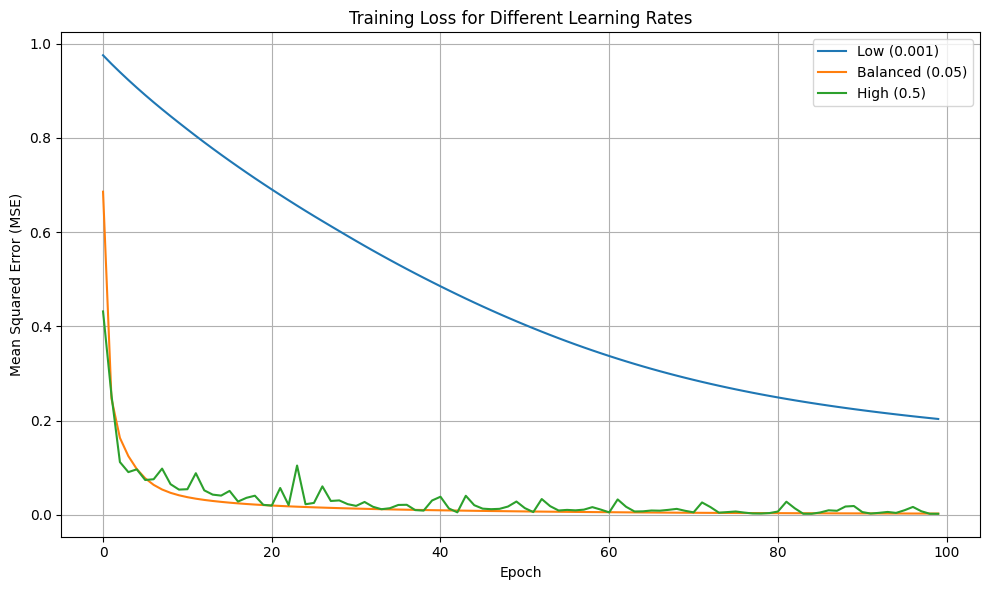

In [24]:
# Plot training loss for all learning rates

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history["loss"],
        label=name
    )

plt.title("Training Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

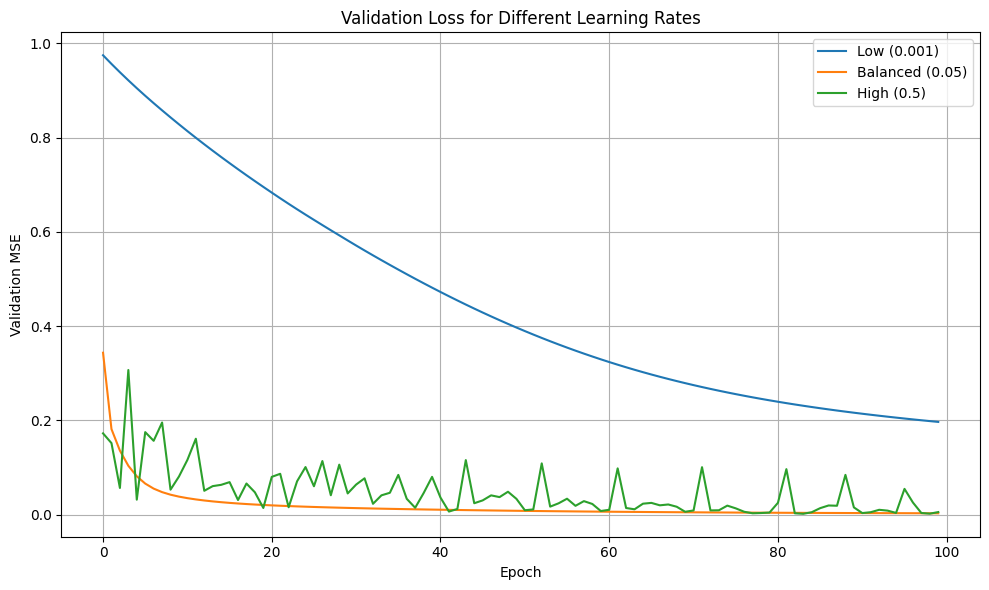

In [25]:
# Plot validation loss for all learning rates

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history["val_loss"],
        label=name
    )

plt.title("Validation Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Identify the learning rate with the lowest test loss

best_result = results_df.loc[
    results_df["Test Loss"].idxmin()
]

best_learning_rate = best_result["Learning Rate"]

print("Best Learning Rate:", best_learning_rate)
print("Test Loss:", best_result["Test Loss"])
print("Test MAE:", best_result["Test MAE"])

Best Learning Rate: 0.05
Test Loss: 0.003676561638712883
Test MAE: 0.03704558685421944


## Learning Rate Analysis

### Low Learning Rate - 0.001

The learning rate of 0.001 produces slow convergence. The loss decreases gradually because the parameter updates are small. Although the model continues learning, it does not reach a sufficiently low error within the selected 100 epochs.

### Balanced Learning Rate - 0.05

The learning rate of 0.05 provides fast and stable convergence. The training and validation losses decrease rapidly and reach low values. It also produces the lowest test loss and test MAE among the three learning rates.

### High Learning Rate - 0.5

The learning rate of 0.5 produces greater fluctuations in the learning curves. The larger parameter updates make the optimization less stable. Its final test performance is slightly worse than the balanced learning rate.

### Overall Comparison

The experiment demonstrates the importance of selecting an appropriate learning rate:

- **0.001** → slow progress
- **0.05** → fast and stable convergence
- **0.5** → greater fluctuation and less stable behavior

Therefore, **0.05 provides the best balance between stability and progress** for this robotic-arm neural-network experiment.

# Conclusion

The experiment analyzed the effect of learning rate on a neural network trained to predict robotic-arm end-effector coordinates.

Three learning rates were evaluated using the SGD optimizer. The results showed that a very small learning rate of **0.001** leads to slow progress, while a high learning rate of **0.5** produces greater fluctuations and slightly poorer final performance.

The learning rate of **0.05** achieved the lowest test loss and test MAE while providing fast and stable convergence.

Therefore, the selected learning rate is:

## **0.05**

This learning rate provides the best balance between training progress, convergence stability, and prediction performance in this experiment.